# Relatório Preliminar – [Analise de dados de processos ambientais]

[Zeca Lucas]
[ML] – [Período]

## 1. Descrição da Base de Dados
* ### **Fonte dos dados:** Sirenejud - https://prd.s3.cnj.jus.br/sirenejud/vw_sirenejud.parquet
* ### **Contextualização:** Os dados do sirenejud é um recorte dos dados do datajud, base processual de metadados.
* ### **Objetivo da utilização:** O propósito é analisar o fluxo processual das demandas ambientais para identificar gargalos e padrões de demora. A base será utilizada para mapear como diferentes assuntos (ex: desmatamento, fauna, poluição) e classes processuais se comportam em termos de celeridade judicial
* ### **Problema de pesquisa:** O problema de pesquisa consiste em responder: "É possível predizer o tempo de tramitação de um processo ambiental, do seu ajuizamento até o primeiro julgamento, com base em seus metadados (assunto, classe, tribunal e valor da causa)?".
Tipo de Aprendizado: Supervisionado.
Abordagem: Regressão (predição do número de dias úteis/corridos).
* ### **O que vai prever?** Tempo de Latência para o Primeiro Julgamento
> A variável target será o Tempo de Latência para o Primeiro Julgamento, calculada pela diferença (em dias) entre a data de ajuizamento do processo e a data do primeiro movimento decisório/julgamento.

---


Base carregada com 34599 registros.
--- Estatísticas de dias_a_dt_primeiro_julgamento ---
count    17918.000000
mean       910.722625
std       1095.617694
min          0.000000
25%        173.000000
50%        519.000000
75%       1157.000000
max       8481.000000
Name: dias_a_dt_primeiro_julgamento, dtype: float64
Coeficiente de Variação: 120.30%


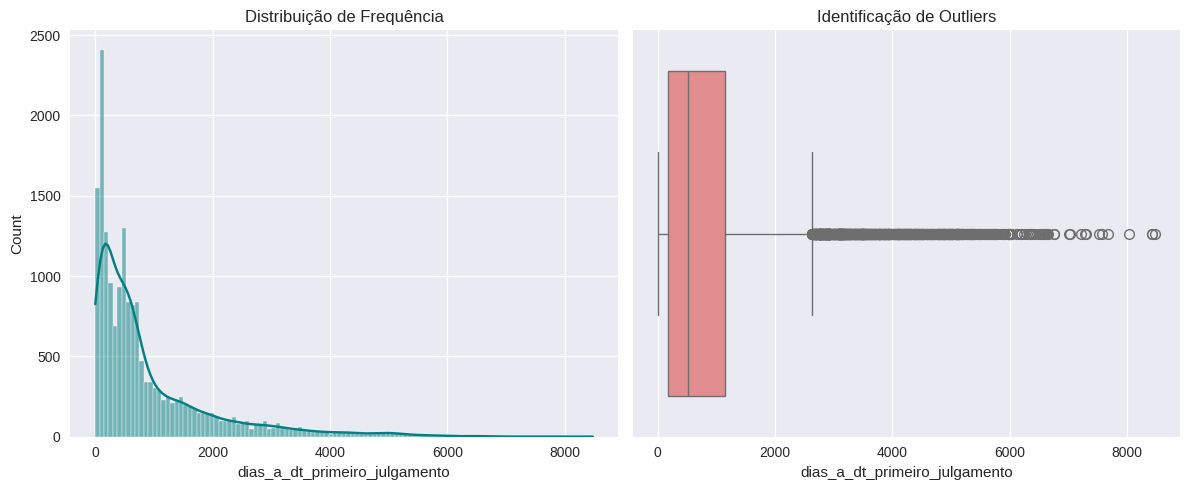

Qualidade da Variável Target:
- Valores ausentes: 16681
- Percentual de incompletude: 48.21%


In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configurações visuais
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

# Carga do arquivo Parquet
df = pd.read_parquet('/home/zeca/tjpa_vw_sirenejud.parquet', engine='pyarrow')
print(f"Base carregada com {len(df)} registros.")



# %% [2] Análises Descritivas (Seção 3.1)
target = 'dias_a_dt_primeiro_julgamento'

# Criando um dicionário de resultados para fácil consulta
stats = df[target].describe()
cv = (stats['std'] / stats['mean']) * 100

print(f"--- Estatísticas de {target} ---")
print(stats)
print(f"Coeficiente de Variação: {cv:.2f}%")

# %% [3] Exploração Gráfica (Seção 3.2)
plt.figure(figsize=(12, 5))

# Histograma e Densidade
plt.subplot(1, 2, 1)
sns.histplot(df[target].dropna(), kde=True, color='teal')
plt.title('Distribuição de Frequência')

# Boxplot para identificar Outliers (conforme pedido no template)
plt.subplot(1, 2, 2)
sns.boxplot(x=df[target], color='lightcoral')
plt.title('Identificação de Outliers')

plt.tight_layout()
plt.show()


# %% [4] Qualidade dos Dados (Seção 4)
nulos = df[target].isnull().sum()
percentual_nulos = (nulos / len(df)) * 100

print(f"Qualidade da Variável Target:")
print(f"- Valores ausentes: {nulos}")
print(f"- Percentual de incompletude: {percentual_nulos:.2f}%")

# Verificando inconsistências em categorias (ex: nomes de tribunais ou assuntos)
# Substitua pelo nome correto da coluna de assunto que você encontrar
if 'nme_assunto_principal' in df.columns:
    print("\nTop 5 Assuntos com mais dados nulos:")
    print(df[df[target].isnull()]['nme_assunto_principal'].value_counts().head(5))



## 2. Dicionário de Dados
O dicionário de dados deve ser entregue **em arquivo separado (Excel)**.  

- Arquivo: `dicionario_dados.xlsx`  
- Conteúdo: variáveis, tipos, unidades de medida e significados.  

> **Exemplo de escrita:**  
> O dicionário de dados (anexo em Excel) apresenta 12 variáveis, entre elas: idade (numérica, anos), renda (numérica, reais), sexo (categórica, masculino/feminino) e consumo_frutas (categórica binária, 1 = consome, 0 = não consome). Cada variável foi descrita com sua unidade de medida e significado, de modo a facilitar futuras análises.

---

## 3. Análises Descritivas Iniciais

### 3.1 Medidas de Posição e Dispersão
Elabore tabelas e/ou resumos estatísticos:  
- Média  
- Mediana  
- Mínimo e Máximo  
- Quartis  
- Desvio-padrão  
- Coeficiente de variação (se aplicável)  
- Outras Medidas

> **Exemplo de escrita:**  
> A variável **idade** apresenta média de 35,2 anos, mediana de 34 anos, mínimo de 18 anos e máximo de 72 anos. O desvio-padrão foi de 10,5 anos, indicando dispersão moderada em relação à média. Já a variável **renda** apresentou grande assimetria, com média de `R$ 3.200,00`, mediana de R$ `2.100,00` e coeficiente de variação de 85%, evidenciando forte desigualdade de rendimentos entre os participantes.

---

### 3.2 Exploração Gráfica
Produza diferentes visualizações gráficas para as variáveis relevantes:  
- Histogramas  
- Boxplots  
- Gráficos de dispersão  
- Outras visualizações que auxiliem na compreensão dos dados

> **Exemplo de escrita:**  
> O histograma da variável **idade** apresenta uma distribuição aproximadamente simétrica em torno dos 30 anos, sugerindo que não há concentração de dados em faixas específicas.  
> O boxplot da variável **renda** revelou a presença de diversos outliers, principalmente acima de R$ 10.000,00, o que sugere a necessidade de tratamento para evitar distorções no modelo.  
> O gráfico de dispersão entre **idade** e **renda** indica que não há relação linear clara entre as duas variáveis, embora famílias mais jovens apresentem maior variação de renda.


## 4. Discussão Preliminar
Na discussão, destaque:  
- Principais padrões ou relações observadas entre as variáveis  
- Questões de qualidade dos dados:
  - Valores ausentes  
  - Dados inconsistentes  
  - Necessidade de padronização (unidades, categorias etc.)  
- Possíveis implicações para a modelagem futura  

> **Exemplo de escrita:**  
> Foi possível observar uma relação entre **renda** e **consumo de frutas**, indicando que famílias com maior poder aquisitivo tendem a consumir frutas com maior frequência. Contudo, algumas variáveis apresentam problemas de qualidade: a variável **idade** possui valores ausentes em 5% das observações, e a variável **sexo** está representada de maneira inconsistente (“M”, “F”, “masc”, “fem”). Esses problemas precisarão ser tratados no pré-processamento para garantir a consistência do modelo.

---

## 5. Próximos Passos
- Ajustes a serem realizados nos dados  
- Definição de variáveis-alvo e preditoras para a modelagem  
- Planejamento inicial de técnicas estatísticas ou de machine learning a serem utilizadas  

> **Exemplo de escrita:**  
> Como próximos passos, será necessário padronizar a variável **sexo**, tratar os valores ausentes de **idade** e aplicar transformações na variável **renda** para reduzir a influência de outliers. A variável-alvo definida para a modelagem será **consumo_frutas**, e como variáveis preditoras serão utilizadas idade, sexo e renda. Pretende-se testar inicialmente modelos de regressão logística e árvores de decisão.

---

## Referências (se necessário)
- Fontes de dados  
- Artigos ou sites de apoio  

> **Exemplo de escrita:**  
> IBGE. Pesquisa de Orçamentos Familiares 2015-2020. Disponível em: [link].  
> Artigo: *Socioeconomic factors and food consumption in Brazil*. Revista Brasileira de Saúde, 2022.  

---